In [9]:
#!/mrhome/amingk/anaconda3/envs/7tpd/bin/python
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
import arviz as az
from scipy.stats import gaussian_kde
from utils import *
import os
from scipy.stats import pearsonr
from scipy import stats

In [10]:
# full model name
model_full_name = 'model1'
# main directory of individual model
main_indv_model_dir =f'{SCRATCH_INDV_MODEL_DIR}/{model_full_name}/'
# merge and save behavioral data with summary model of paramter
combine_parameter_highRewardChoice(main_indv_model_dir=main_indv_model_dir, param='weight', model=model_full_name)

In [11]:
# read behavioral data with summary paramter
df_beh_paramerer = pd.read_csv(PROJECT_NoNAN_BEH_REL_IRREL_HIGH_REWARD_OPTION_GROUPBY_ALL_FILE_MODEL_PARAMETER)

In [12]:
PROJECT_NoNAN_BEH_REL_IRREL_HIGH_REWARD_OPTION_GROUPBY_ALL_FILE_MODEL_PARAMETER

'/mnt/projects/7TPD/bids/derivatives/fMRI_DA/AllBehData/NoNanBehAll_RelIrrelHighReward_Groupby_ModelParameter.csv'

In [13]:
# make a groupby and everage across sessions in HC
df_beh_paramerer_groupby = df_beh_paramerer.groupby(['patient', 'sub_ID'])[['relevantHighRewardOption', 'irrelevantHighRewardOption',
                                                                            'relevantVsIrrelevantHighRewardOption', 'weight_parameter_map',
                                                                            'weight_parameter_map_magnitude']].mean().reset_index()

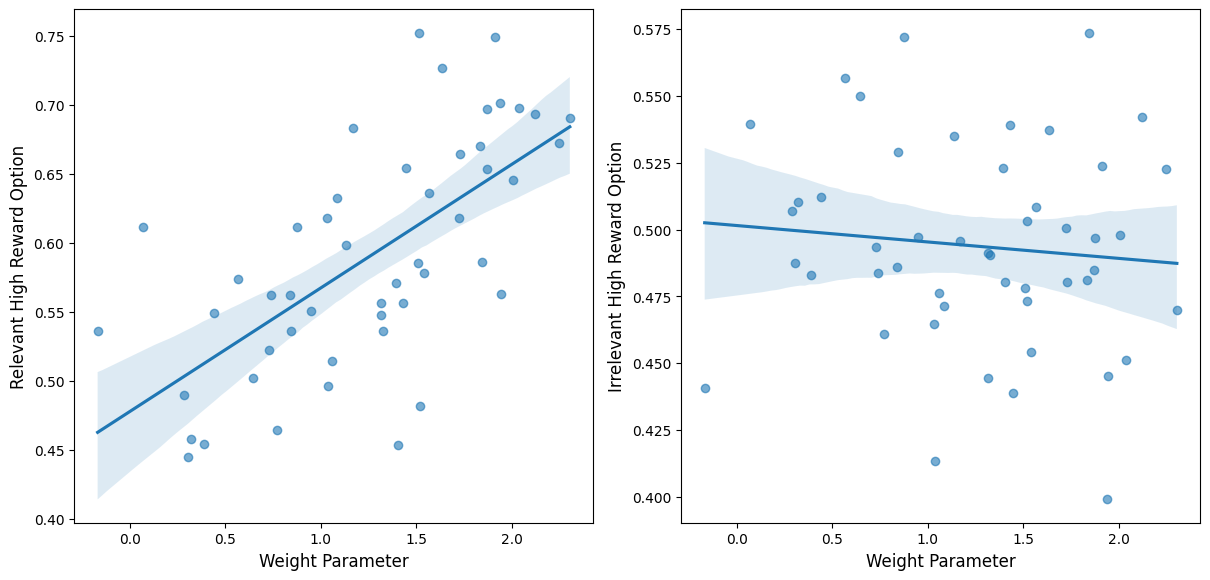

In [14]:
# plot of correlation for relevant condition
cm = 1/2.54  # centimeters in inches
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(31*cm, 15*cm))
axs=axs.flatten()

sns.regplot(data=df_beh_paramerer_groupby,x="weight_parameter_map_magnitude",y="relevantHighRewardOption",
    ax=axs[0],scatter_kws={"alpha": 0.6})

axs[0].set_xlabel("Weight Parameter", fontsize=12)
axs[0].set_ylabel("Relevant High Reward Option", fontsize=12)

sns.regplot(data=df_beh_paramerer_groupby,x="weight_parameter_map_magnitude",y="irrelevantHighRewardOption",
            ax=axs[1], scatter_kws={"alpha": 0.6})

axs[1].set_xlabel("Weight Parameter", fontsize=12)
axs[1].set_ylabel("Irrelevant High Reward Option", fontsize=12)


# Save image
plt.tight_layout()

plt.savefig(f'{FIGURES_DIR}/corr_beh_parameter_relevant.pdf', dpi=500)

plt.show()

[]

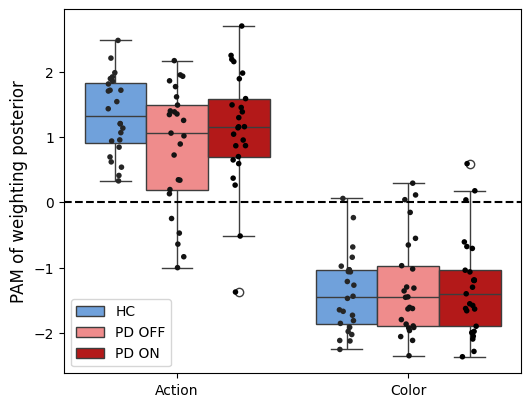

In [15]:
# copy of dataframe for plotting
df_beh_paramerer_plot = df_beh_paramerer.copy()
# Standardize group and condition labels
df_beh_paramerer_plot['group'] = df_beh_paramerer_plot['group'].replace([1,2,3], ['PD OFF', 'HC', 'PD ON'])
df_beh_paramerer_plot['Condition'] = df_beh_paramerer_plot['block'].replace(['Act', 'Stim'], ['Action', 'Color'])
group_order = ['HC', 'PD OFF', 'PD ON']
# Plot setting 
mm = 1/2.54  # convert cm to zinches for figure size
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15*mm, 12*mm))
#axs = axs.flatten()
    
# Custom color palette
custom_palette = {'HC': COLORS['HC'], 'PD ON': COLORS['PD-ON'], 'PD OFF': COLORS['PD-OFF']}

# relevant high Reward Option 
sns.boxplot(data=df_beh_paramerer_plot, x='Condition', y='weight_parameter_map', hue='group', ax=axs,
            palette=custom_palette, hue_order=group_order)
sns.stripplot(data=df_beh_paramerer_plot, x='Condition', y='weight_parameter_map', hue='group', ax=axs,
                dodge=True, alpha=1, size=4, legend=False, palette='dark:black', hue_order=group_order)
axs.set_ylabel('PAM of weighting posterior', fontsize=12)
axs.set_xlabel('', fontsize=12)
axs.axhline(0, color='black', linestyle='--')
#axs.set_ylim(0,1)
axs.legend(fontsize=10, loc="lower left")

plt.savefig(f'{FIGURES_DIR}/individual_map_parameter_relevant.pdf', dpi=500)

plt.plot()